# FIFA World Cup 2026: A Statistical Analysis of Match Performance and Winning
### Four analytical tasks using descriptive statistics, confidence intervals and two-sample t-tests

---

## 1. Introduction

The FIFA World Cup 2026, hosted by Canada, Mexico and the United States (11 June – 19 July 2026), was the first
48-team World Cup, comprising **104 matches** that produced 308 goals. Spain won the tournament, defeating
Argentina 1–0 after extra time in the final, with England taking third place.

The expansion to 104 matches makes this the largest single-tournament sample in World Cup history, which is a
methodological opportunity: match-level inferential statistics that were fragile with 64 observations per side
become considerably more stable with 208 team-match observations.

**Objectives.** A distinct analytical task with its own research question, wrangling, sampling rationale,
descriptive statistics, 95% confidence intervals, explicit hypotheses, assumption checking, a two-sample t-test,
effect size and interpretation:


Significance level for all inferential tests: **α = 0.05** (two-sided).

In [1]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 160, 'savefig.bbox': 'tight'})
PALETTE = {'Win': '#B8860B', 'Not win': '#36454F'}   # gold vs charcoal
os.makedirs('figures', exist_ok=True)
RNG_DATE_ACCESSED = '2026-09-09'
print('Environment ready. Data accessed:', RNG_DATE_ACCESSED)

Environment ready. Data accessed: 2026-09-09


## 2. Data Sources and Acquisition

The assignment brief lists three reference sources for FIFA World Cup 2026 statistics: the **FIFA official
website**, **The Stats Don't Lie**, and **FBref**. Direct programmatic scraping of these sites is technically
restricted (FIFA's statistics hub is a JavaScript application without a public bulk endpoint, and FBref's terms
discourage automated bulk scraping). Following the brief's instruction to *"identify alternative accessible
pages/endpoints … or create CSV files from legally accessible publicly available data"*, we used a public,
openly licensed relational dataset that compiles exactly these statistics with per-row source traceability:

| Item | Detail |
|---|---|
| Dataset | *FIFA World Cup 2026 Dataset* (relational CSV tables) |
| Repository | `https://github.com/mominullptr/FIFA-World-Cup-2026-Dataset` |
| Acquisition method | `git clone` (reproducible; commit pinned at access date) |
| Date accessed | 9 September 2026 |
| Underlying providers | `fifa.com` (96 team-match rows) and `sofascore.com` (112 team-match rows), recorded per row in a `data_source` column |
| Tables used | `matches.csv` (104 rows × 17), `match_team_stats.csv` (208 rows × 12), `matches_detailed.csv`, `teams.csv`, `tournament_stages.csv`, `match_events.csv` |
| Fabrication policy | The dataset maintains a hard rule of **no synthetic match statistics**; fields are populated only when confirmed from real sources |

**Independent verification.** Before analysis we cross-checked the dataset against the public tournament record
(FIFA/Wikipedia): the opening match (Mexico 2–0 South Africa), the final (Spain 1–0 Argentina, AET), the
third-place match (France 4–6 England), the tournament goal total (308) and the top scorer (Kylian Mbappé, 10
goals) all match exactly. This validation is reproduced in Section 4.

Raw files are preserved unmodified in `data/raw/`; every transformation happens in code below, and the cleaned
analysis table is written to `cleaned_data.csv`.

In [6]:
RAW = '/content/drive/MyDrive/data/raw'
matches   = pd.read_csv(f'{RAW}/matches.csv')
team_stats= pd.read_csv(f'{RAW}/match_team_stats.csv')
detailed  = pd.read_csv(f'{RAW}/matches_detailed.csv')
teams     = pd.read_csv(f'{RAW}/teams.csv')
stages    = pd.read_csv(f'{RAW}/tournament_stages.csv')
events    = pd.read_csv(f'{RAW}/match_events.csv')
print(f'matches: {matches.shape} | team_stats: {team_stats.shape} | teams: {teams.shape} | events: {events.shape}')

matches: (104, 17) | team_stats: (208, 12) | teams: (48, 8) | events: (601, 6)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Data Understanding

The unit of observation differs by table: `matches.csv` is one row per **match** (104), while
`match_team_stats.csv` is one row per **team-match** (208 = 104 × 2), which is the unit our research questions
require (each team's performance in each match).

In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                104 non-null    int64  
 1   date                    104 non-null    object 
 2   kickoff_time_utc        104 non-null    object 
 3   stage_id                104 non-null    int64  
 4   venue_id                104 non-null    int64  
 5   home_team_id            104 non-null    int64  
 6   away_team_id            104 non-null    int64  
 7   home_score              104 non-null    int64  
 8   away_score              104 non-null    int64  
 9   home_penalty_score      3 non-null      float64
 10  away_penalty_score      3 non-null      float64
 11  status                  104 non-null    object 
 12  result_type             104 non-null    object 
 13  home_xg                 104 non-null    float64
 14  away_xg                 104 non-null    fl

In [8]:
team_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             208 non-null    int64 
 1   team_id              208 non-null    int64 
 2   possession_pct       208 non-null    int64 
 3   total_shots          208 non-null    int64 
 4   shots_on_target      208 non-null    int64 
 5   corners              208 non-null    int64 
 6   fouls                208 non-null    int64 
 7   offsides             208 non-null    int64 
 8   saves                208 non-null    int64 
 9   player_of_the_match  104 non-null    object
 10  data_source          208 non-null    object
 11  last_updated         208 non-null    object
dtypes: int64(9), object(3)
memory usage: 19.6+ KB


In [9]:
team_stats.describe().round(2)

,match_id,team_id,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves
count,208.00,208.00,208.00,208.00,208.00,208.00,208.00,208.00,208.00
mean,52.50,25.06,48.69,12.30,4.38,4.61,10.89,1.58,3.29
std,30.09,13.86,11.97,5.79,2.77,2.92,3.22,0.99,2.28
min,1.00,1.00,19.00,2.00,0.00,0.00,1.00,0.00,0.00
25%,26.75,13.00,41.00,8.00,2.00,3.00,9.00,1.00,2.00
50%,52.50,26.00,49.00,11.00,4.00,4.00,11.00,1.00,3.00
75%,78.25,37.00,58.00,15.00,6.00,6.00,13.00,2.00,4.00
max,104.00,48.00,76.00,33.00,15.00,19.00,24.00,5.00,15.00


In [10]:
# Which providers supplied the team-match statistics?
team_stats['data_source'].value_counts()

,count
data_source,
sofascore.com,112
fifa.com,96


## 4. Data Cleaning and Validation

We check, in order: missing values, duplicates, invalid ranges, internal consistency, cross-source consistency,
and consistency with the public tournament record. **Every cleaning decision is documented; no observation is
silently deleted.**

In [11]:
print('--- Missing values (matches) ---')
print(matches.isnull().sum()[matches.isnull().sum() > 0])
print('\n--- Missing values (team_stats) ---')
ms = team_stats.isnull().sum(); print(ms[ms > 0])
print('\nDuplicate matches:', matches.duplicated('match_id').sum())
print('Duplicate team-match rows:', team_stats.duplicated(['match_id','team_id']).sum())
print('Match status values:', matches['status'].unique())

--- Missing values (matches) ---
home_penalty_score    101
away_penalty_score    101
dtype: int64

--- Missing values (team_stats) ---
player_of_the_match    104
dtype: int64

Duplicate matches: 0
Duplicate team-match rows: 0
Match status values: ['Completed']


*Finding:* the only missing values are structurally missing (penalty scores exist only for shoot-out matches;
`player_of_the_match` is recorded for one team per match). No analytical variable has missing data, there are no
duplicates, and all 104 matches are `Completed`.

In [12]:
# Range validity
print('Possession outside [0,100]:', ((team_stats.possession_pct < 0) | (team_stats.possession_pct > 100)).sum())
print('Negative counts:', (team_stats[['total_shots','shots_on_target','corners','fouls']] < 0).sum().sum())
print('Shots on target > total shots:', (team_stats.shots_on_target > team_stats.total_shots).sum())
print('Impossible scores:', ((matches.home_score < 0) | (matches.away_score < 0)).sum())
print('xG missing or negative:', ((matches[['home_xg','away_xg']] < 0) | matches[['home_xg','away_xg']].isnull()).sum().sum())

# Internal consistency: do the two possession values per match sum to 100?
pair_sum = team_stats.groupby('match_id')['possession_pct'].sum()
print('\nPossession pair-sum distribution:')
print(pair_sum.value_counts().sort_index())

Possession outside [0,100]: 0
Negative counts: 0
Shots on target > total shots: 0
Impossible scores: 0
xG missing or negative: 0

Possession pair-sum distribution:
possession_pct
81      1
85      2
86      3
87      2
88      1
89      5
90      3
91      4
92      1
93      2
100    80
Name: count, dtype: int64


*Finding:* 80 of 104 matches have possession summing to exactly 100; in 24 matches the pair sums to 81–93.
Inspection of the `data_source` column shows these are matches recorded by a provider that reports *contested/neutral
possession* separately, so the two teams' shares do not sum to 100. This is a **measurement difference between
sources**, not a data error. We keep the raw values for the primary analysis (they are the officially reported
figures) and run a normalised-possession sensitivity check in Task 1 (§5.9) to confirm the conclusion is unaffected.

In [13]:
# Cross-check against the public tournament record
final = detailed[detailed.stage_name == 'Final'].iloc[0]
opener = detailed.iloc[0]
third = detailed[detailed.stage_name == 'Third-place match'].iloc[0]
checks = pd.DataFrame([
    ['Opening match', f"{opener.home_team_name} {opener.home_score}-{opener.away_score} {opener.away_team_name}", 'Mexico 2-0 South Africa'],
    ['Final', f"{final.home_team_name} {final.home_score}-{final.away_score} {final.away_team_name} ({final.result_type})", 'Spain 1-0 Argentina (AET)'],
    ['Third place', f"{third.home_team_name} {third.home_score}-{third.away_score} {third.away_team_name}", 'France 4-6 England'],
    ['Total goals', int(matches.home_score.sum() + matches.away_score.sum()), '308 (FIFA)'],
    ['Matches', len(matches), '104 (FIFA)'],
], columns=['Check', 'Dataset value', 'Public record'])
checks

,Check,Dataset value,Public record
0,Opening match,Mexico 2-0 South Africa,Mexico 2-0 South Africa
1,Final,Spain 1-0 Argentina (AET),Spain 1-0 Argentina (AET)
2,Third place,France 4-6 England,France 4-6 England
3,Total goals,308,308 (FIFA)
4,Matches,104,104 (FIFA)


### 4.2 Constructing the analysis table (data wrangling)

We reshape the match-level table to the **team-match** level (two rows per match), merge the team statistics, and
derive the outcome variables. The binary outcome is:

> **win = 1** if the team scored more goals than its opponent within regulation or extra time; **win = 0** otherwise
> (defeats *and* draws).

Justification: (i) the research questions contrast winning with not winning, and pooling draws with defeats gives
two well-sized groups (80 vs 128) instead of three small ones; (ii) in the three penalty shoot-outs, neither team
won *in play* — the shoot-out is a tie-breaking lottery unrelated to in-match performance statistics — so both
teams are coded `win = 0` and this choice is revisited in the limitations.

In [14]:
def to_long(m):
    h = m[['match_id','date','stage_id','home_team_id','away_team_id','home_score','away_score','home_xg','away_xg','result_type']].copy()
    h.columns = ['match_id','date','stage_id','team_id','opponent_id','goals_for','goals_against','xg','xg_against','result_type']
    h['is_home'] = 1
    a = m[['match_id','date','stage_id','away_team_id','home_team_id','away_score','home_score','away_xg','home_xg','result_type']].copy()
    a.columns = h.columns[:-1]
    a['is_home'] = 0
    return pd.concat([h, a], ignore_index=True)

df = (to_long(matches)
      .merge(team_stats.drop(columns=['player_of_the_match','last_updated']), on=['match_id','team_id'])
      .merge(teams[['team_id','team_name','confederation']], on='team_id')
      .merge(teams[['team_id','team_name']].rename(columns={'team_id':'opponent_id','team_name':'opponent_name'}), on='opponent_id')
      .merge(stages, on='stage_id'))

df['result'] = np.select([df.goals_for > df.goals_against, df.goals_for < df.goals_against], ['W','L'], default='D')
df['win'] = (df.result == 'W').astype(int)
df['outcome'] = df.win.map({1: 'Win', 0: 'Not win'})

# Own-goal adjustment for Task 3: an own goal by the OPPONENT inflates goals_for without a shot by this team.
og = (events[events.event_type == 'Own Goal'].groupby(['match_id','team_id']).size()
      .rename('own_goals_committed').reset_index())
df = df.merge(og.rename(columns={'team_id':'opponent_id','own_goals_committed':'opp_own_goals'}),
              on=['match_id','opponent_id'], how='left')
df['opp_own_goals'] = df['opp_own_goals'].fillna(0).astype(int)
df['goals_from_play'] = df.goals_for - df.opp_own_goals
df['conversion_rate'] = df.goals_from_play / df.total_shots * 100     # no team had 0 shots (verified below)

print('Rows:', len(df), '| teams with zero shots:', (df.total_shots == 0).sum())
print('Outcome counts:', df.outcome.value_counts().to_dict())
df.head(3)

Rows: 208 | teams with zero shots: 0
Outcome counts: {'Not win': 128, 'Win': 80}


,match_id,date,stage_id,team_id,opponent_id,goals_for,goals_against,xg,xg_against,result_type,...,confederation,opponent_name,stage_name,is_knockout,result,win,outcome,opp_own_goals,goals_from_play,conversion_rate
0,1,2026-06-11,1,1,2,2,0,1.84,0.52,Regular,...,CONCACAF,South Africa,Group Stage,False,W,1,Win,0,2,12.500000
1,2,2026-06-11,1,3,4,2,1,1.45,1.12,Regular,...,AFC,Czechia,Group Stage,False,W,1,Win,0,2,16.666667
2,3,2026-06-12,1,5,6,1,1,1.35,0.98,Regular,...,CONCACAF,Bosnia and Herzegovina,Group Stage,False,D,0,Not win,0,1,7.692308


In [15]:
# Variable dictionary for the cleaned analysis table
var_dict = pd.DataFrame([
 ['match_id',        'Match identifier (1-104)',                        'Categorical ID', '-',      'Key'],
 ['team_name',       'Team',                                            'Categorical',    '-',      'Key'],
 ['opponent_name',   'Opponent',                                        'Categorical',    '-',      'Context'],
 ['stage_name',      'Tournament stage',                                'Categorical',    '-',      'Context/moderator'],
 ['is_knockout',     'Knockout stage flag',                             'Binary',         '0/1',    'Moderator'],
 ['goals_for',       'Goals scored (incl. opponent own goals)',         'Discrete',       'goals',  'Outcome/context'],
 ['goals_against',   'Goals conceded',                                  'Discrete',       'goals',  'Context'],
 ['result',          'Match result in play (90min/ET)',                 'Categorical',    'W/D/L',  'Grouping (raw)'],
 ['win',             '1 = won in play, 0 = draw or loss',               'Binary',         '0/1',    'Grouping variable'],
 ['possession_pct',  'Ball possession',                                 'Continuous',     '%',      'DV Task 1'],
 ['fouls',           'Fouls committed',                                 'Discrete',       'count',  'DV Task 2'],
 ['goals_from_play', 'Goals excluding opponent own goals',              'Discrete',       'goals',  'Task 3 numerator'],
 ['total_shots',     'Total shots attempted',                           'Discrete',       'count',  'Task 3 denominator'],
 ['conversion_rate', 'goals_from_play / total_shots x 100',             'Continuous',     '%',      'DV Task 3'],
 ['xg',              'Expected goals created',                          'Continuous',     'xG',     'DV Task 4'],
 ['shots_on_target', 'Shots on target',                                 'Discrete',       'count',  'Heatmap/context'],
 ['corners',         'Corner kicks',                                    'Discrete',       'count',  'Heatmap/context'],
 ['data_source',     'Statistics provider for this row',                'Categorical',    '-',      'Provenance'],
], columns=['Variable','Description','Type','Unit','Role'])
var_dict.to_csv('data_dictionary.csv', index=False)
df.to_csv('cleaned_data.csv', index=False)
print('Wrote cleaned_data.csv ({} rows) and data_dictionary.csv'.format(len(df)))
var_dict

Wrote cleaned_data.csv (208 rows) and data_dictionary.csv


,Variable,Description,Type,Unit,Role
0,match_id,Match identifier (1-104),Categorical ID,-,Key
1,team_name,Team,Categorical,-,Key
2,opponent_name,Opponent,Categorical,-,Context
3,stage_name,Tournament stage,Categorical,-,Context/moderator
4,is_knockout,Knockout stage flag,Binary,0/1,Moderator
5,goals_for,Goals scored (incl. opponent own goals),Discrete,goals,Outcome/context
6,goals_against,Goals conceded,Discrete,goals,Context
7,result,Match result in play (90min/ET),Categorical,W/D/L,Grouping (raw)
8,win,"1 = won in play, 0 = draw or loss",Binary,0/1,Grouping variable
9,possession_pct,Ball possession,Continuous,%,DV Task 1


### 4.4 Shared inference machinery

The task implements one protocal: group descriptives →
95% CIs (t-distribution) → assumption checks (Shapiro–Wilk, Levene, boxplot/IQR outliers) → **Welch's two-sample
t-test** (robust to unequal variances; Welch is the pre-registered default per the brief) → Cohen's *d* →
Mann–Whitney U as a non-parametric sensitivity analysis.

In [16]:
def describe_groups(data, var):
    g = data.groupby('outcome')[var]
    out = g.agg(n='count', mean='mean', median='median', sd='std', var_='var',
                min='min', q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75), max='max')
    out['IQR'] = out.q3 - out.q1
    out['range'] = out['max'] - out['min']
    return out.round(2).loc[['Win','Not win']]

def mean_ci(x, conf=0.95):
    x = np.asarray(x.dropna() if hasattr(x, 'dropna') else x, float)
    n = len(x); m = x.mean(); se = x.std(ddof=1)/np.sqrt(n)
    t = stats.t.ppf((1+conf)/2, n-1)
    return m, m-t*se, m+t*se

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean()-b.mean())/sp

def run_inference(data, var, label):
    w, nw = data.loc[data.win==1, var].dropna(), data.loc[data.win==0, var].dropna()
    res = {}
    res['shapiro'] = {g: stats.shapiro(x).pvalue for g, x in [('Win', w), ('Not win', nw)]}
    res['levene_p'] = stats.levene(w, nw).pvalue
    tt = stats.ttest_ind(w, nw, equal_var=False)
    ci = tt.confidence_interval()
    res.update(t=tt.statistic, df=tt.df, p=tt.pvalue, diff=w.mean()-nw.mean(),
               diff_ci=(ci.low, ci.high), d=cohens_d(w, nw),
               mwu_p=stats.mannwhitneyu(w, nw, alternative='two-sided').pvalue,
               ci_win=mean_ci(w), ci_nw=mean_ci(nw))
    print(f'=== {label} ===')
    print(f"Shapiro-Wilk p: Win={res['shapiro']['Win']:.4g}, Not win={res['shapiro']['Not win']:.4g} | Levene p={res['levene_p']:.4g}")
    print(f"Welch t({res['df']:.1f}) = {res['t']:.3f}, p = {res['p']:.3g}")
    print(f"Mean difference = {res['diff']:.2f}, 95% CI ({res['diff_ci'][0]:.2f}, {res['diff_ci'][1]:.2f}), Cohen's d = {res['d']:.2f}")
    print(f"Win mean {res['ci_win'][0]:.2f} 95% CI ({res['ci_win'][1]:.2f}, {res['ci_win'][2]:.2f}) | "
          f"Not-win mean {res['ci_nw'][0]:.2f} 95% CI ({res['ci_nw'][1]:.2f}, {res['ci_nw'][2]:.2f})")
    print(f"Sensitivity Mann-Whitney U p = {res['mwu_p']:.3g}")
    return res

def ci_plot(data, var, label, unit, fname):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for i, g in enumerate(['Win','Not win']):
        m, lo, hi = mean_ci(data.loc[data.outcome==g, var])
        ax.errorbar(i, m, yerr=[[m-lo],[hi-m]], fmt='o', ms=11, capsize=8, lw=2.4,
                    color=PALETTE[g], ecolor=PALETTE[g])
        ax.annotate(f'{m:.1f}', (i, m), xytext=(14, 0), textcoords='offset points', fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Winners','Non-winners']); ax.set_xlim(-.5, 1.5)
    ax.set_ylabel(f'{label} ({unit})'); ax.set_title(f'Mean {label.lower()} with 95% confidence intervals\nFIFA World Cup 2026, team-matches (n=208)')
    fig.savefig(f'figures/{fname}'); plt.show()

---
## 5. Analytical Task  — Ball Possession and Winning

### 5.1 Research question
**Does a team's ball possession significantly differ between matches that it wins and matches that it does not win
at the FIFA World Cup 2026?**

This is non-trivial: the "possession football" era (Spain 2010, tiki-taka) argued that controlling the ball wins
matches, while counter-pressing and low-block counter-attacking sides (e.g. France 2018) suggested the opposite.
The 2026 tournament — won by a high-possession Spain side — is a natural setting to quantify the association.

### 5.2 Population, sample and unit of analysis
| Element | Definition |
|---|---|
| Target population | Team-match performances in elite senior men's international tournament football of the current era |
| Sampling frame / sample | All 208 team-match performances at the FIFA World Cup 2026 |
| Unit of analysis | One team's performance in one match (team-match) |
| Sampling strategy | Census of the accessible frame — a complete enumeration of the 2026 tournament, treated as a sample from the wider population of tournament football when generalising |
| Sample size | n = 208 (80 wins, 128 non-wins) |
| Inclusion criteria | All completed tournament matches (104/104); no exclusions |

We do **not** claim the 208 observations are a random sample; they are the full 2026 tournament. Inference is
justified under the standard "process view": each match outcome is one realisation of a stochastic process, and we
generalise to that process (tournament football of this era), not merely describe the fixed 2026 results.

### 5.3 Data preparation
`possession_pct` is complete (0 missing), within [0,100] for all rows, and the grouping variable `win` was derived
in §4.2 (Win = 1 for victory in regulation/extra time; draws and shoot-out matches coded 0, justification in §4.2).

In [17]:
t1 = describe_groups(df, 'possession_pct')
t1

,n,mean,median,sd,var_,min,q1,q3,max,IQR,range
outcome,,,,,,,,,,,
Win,80,55.12,56.5,10.04,100.87,19,50.0,62.00,76,12.00,57
Not win,128,44.67,44.0,11.33,128.29,20,37.0,51.25,76,14.25,56


### 5.4 Descriptive findings
Winners average **55.1%** possession against **44.7%** for non-winners — a gap of more than 10 percentage points.
The medians (56.5 vs 44.0) tell the same story, so the difference is not driven by a handful of extreme matches,
and spread is similar in both groups (SD ≈ 10–11).

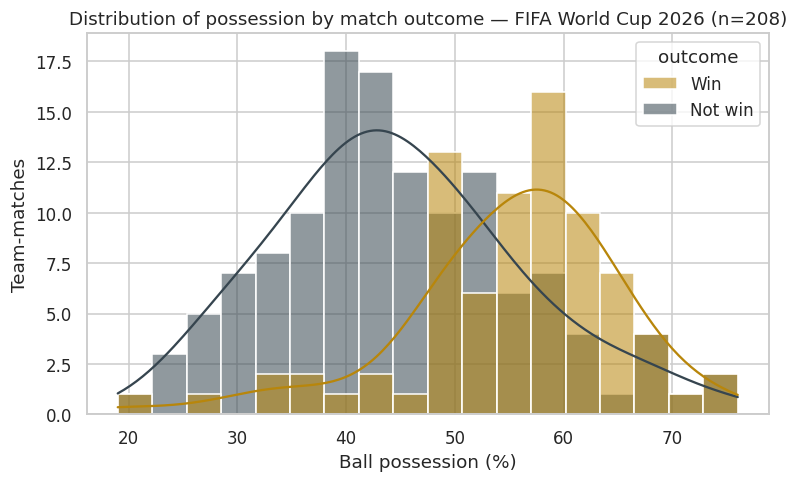

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=df, x='possession_pct', hue='outcome', bins=18, kde=True,
             palette=PALETTE, alpha=.55, ax=ax)
ax.set(xlabel='Ball possession (%)', ylabel='Team-matches',
       title='Distribution of possession by match outcome — FIFA World Cup 2026 (n=208)')
fig.savefig('figures/t1_hist.png'); plt.show()

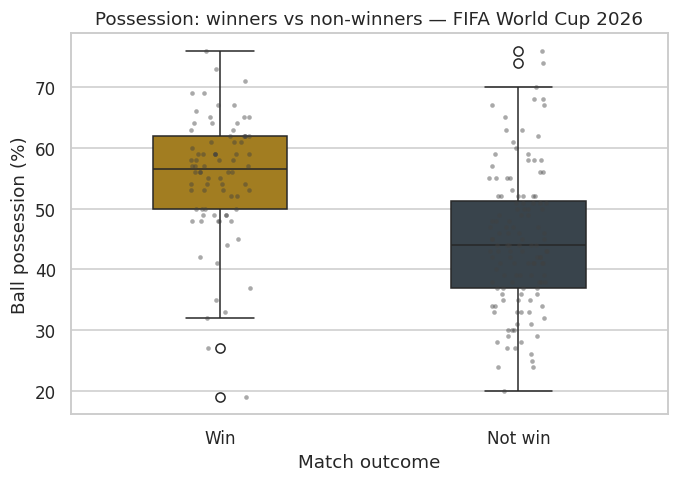

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x='outcome', y='possession_pct', order=['Win','Not win'],
            palette=PALETTE, width=.45, ax=ax)
sns.stripplot(data=df, x='outcome', y='possession_pct', order=['Win','Not win'],
              color='.25', size=3, alpha=.45, ax=ax)
ax.set(xlabel='Match outcome', ylabel='Ball possession (%)',
       title='Possession: winners vs non-winners — FIFA World Cup 2026')
fig.savefig('figures/t1_box.png'); plt.show()

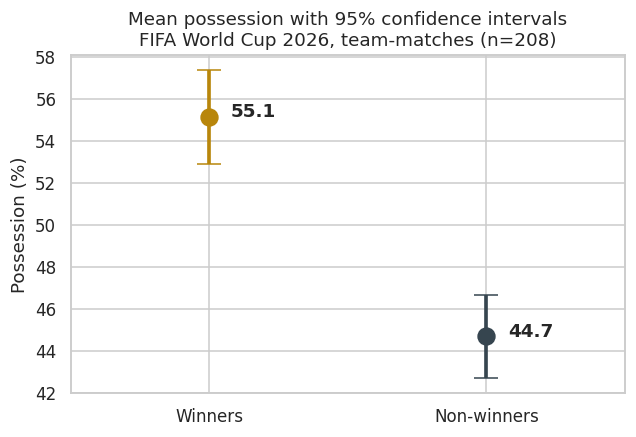

In [20]:
ci_plot(df, 'possession_pct', 'Possession', '%', 't1_ci.png')

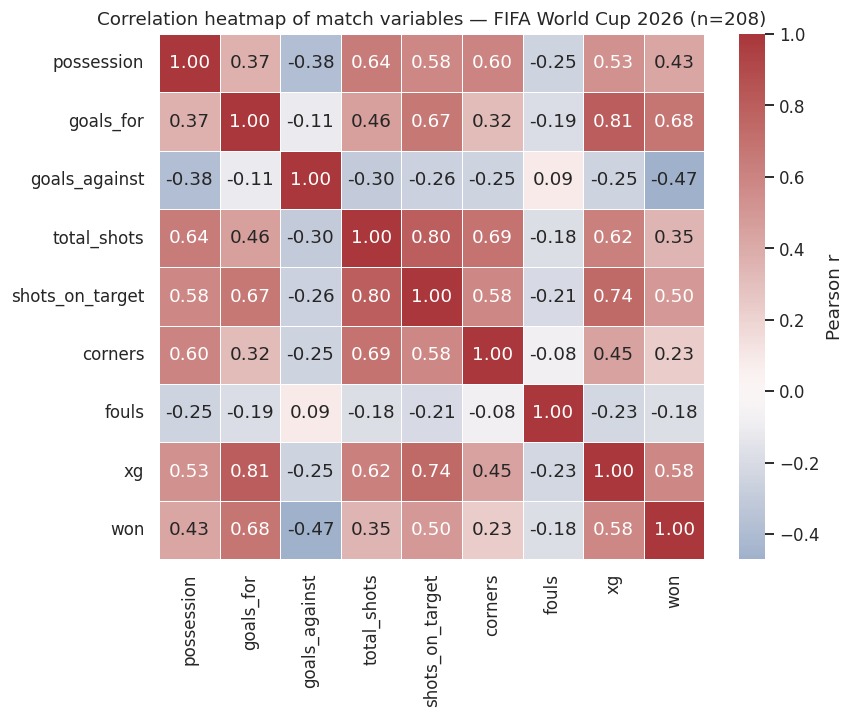

In [21]:
# Correlation heatmap of the numeric match variables (association, NOT causation)
num = df[['possession_pct','goals_for','goals_against','total_shots','shots_on_target',
          'corners','fouls','xg','win']].rename(columns={'possession_pct':'possession','win':'won'})
fig, ax = plt.subplots(figsize=(8, 6.2))
sns.heatmap(num.corr().round(2), annot=True, cmap='vlag', center=0, fmt='.2f',
            linewidths=.5, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation heatmap of match variables — FIFA World Cup 2026 (n=208)')
fig.savefig('figures/t1_heatmap.png'); plt.show()

*Heatmap reading (association only):* possession correlates positively with shots (r ≈ .67), corners and
shots on target — possession-dominant teams generate more attacking volume — and moderately with winning
(r ≈ .43). Fouls correlate *negatively* with possession (you cannot foul while you hold the ball), foreshadowing
Task 2. None of these correlations establishes causation.

### 5.5 Confidence intervals
The parameters being estimated are the **population mean possession of winning team-matches**, of **non-winning
team-matches**, and their **difference**, in the tournament-football process the 2026 data realises. A t-based 95%
CI is appropriate: possession is continuous, groups are large (80 and 128), and the CLT makes the sample mean
approximately normal. *Interpretation note:* a 95% CI does **not** mean there is a 95% probability the parameter
lies in this specific interval; it means the interval-generating procedure captures the true parameter in 95% of
repeated samples.

### 5.6 Hypotheses
- **H₀:** μ_win = μ_not-win — mean possession does not differ between winning and non-winning team-matches.
- **H₁:** μ_win ≠ μ_not-win — mean possession differs (two-sided; no strong prior direction is imposed, since both
  possession-dominant and counter-attacking winning styles are plausible).
- α = 0.05. Decision rule: reject H₀ if p < 0.05.

### 5.7 Assumption checking

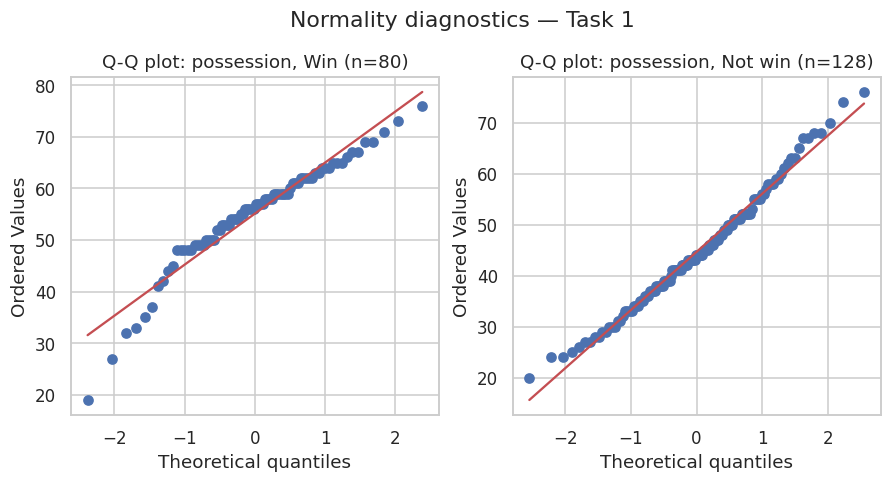

Win: IQR outliers = 2 [19, 27]
Not win: IQR outliers = 2 [74, 76]


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, g in zip(axes, ['Win','Not win']):
    stats.probplot(df.loc[df.outcome==g, 'possession_pct'], dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot: possession, {g} (n={ (df.outcome==g).sum() })')
fig.suptitle('Normality diagnostics — Task 1', y=1.03)
fig.savefig('figures/t1_qq.png'); plt.show()

for g in ['Win','Not win']:
    x = df.loc[df.outcome==g, 'possession_pct']
    q1, q3 = x.quantile([.25,.75]); iqr = q3-q1
    out = x[(x < q1-1.5*iqr) | (x > q3+1.5*iqr)]
    print(f'{g}: IQR outliers = {len(out)}', sorted(out.tolist()))

- **Independence:** each row is a distinct team-match; the caveat that teams and matches repeat is discussed
  in §5.10 and §12 — this is the analysis's main structural limitation.
- **Continuous DV:** possession in % — satisfied.
- **Normality:** Q-Q plots are close to linear; Shapiro–Wilk flags mild non-normality in the winners group
  (p ≈ .001), unsurprising at n = 80 where the test is sensitive to trivial departures. With group sizes of 80 and
  128 the t-test is robust via the CLT; the Mann–Whitney sensitivity test below guards the conclusion.
- **Outliers:** the IQR rule flags no extreme possession values requiring action; all values are genuine matches
  (extremes correspond to real one-sided games) and are retained.
- **Equal variances:** Levene's p ≈ .11 — no strong evidence of inequality, but Welch's test is used regardless as
  the more robust default.

### 5.8 Welch's two-sample t-test, effect size and sensitivity analysis

In [23]:
r1 = run_inference(df, 'possession_pct', 'Task 1: possession (Win vs Not win)')

=== Task 1: possession (Win vs Not win) ===
Shapiro-Wilk p: Win=0.001186, Not win=0.2289 | Levene p=0.1123
Welch t(182.7) = 6.949, p = 6.29e-11
Mean difference = 10.45, 95% CI (7.48, 13.42), Cohen's d = 0.96
Win mean 55.12 95% CI (52.89, 57.36) | Not-win mean 44.67 95% CI (42.69, 46.65)
Sensitivity Mann-Whitney U p = 4.03e-11


### 5.9 Sensitivity: normalised possession
Because 24 matches report possession pairs summing below 100 (§4), we re-run the test on each team's *share* of
reported possession, `possession / pair_sum × 100`, which removes the between-provider convention difference.

In [24]:
pair = df.groupby('match_id')['possession_pct'].transform('sum')
df['possession_share'] = df.possession_pct / pair * 100
w, nw = df.loc[df.win==1,'possession_share'], df.loc[df.win==0,'possession_share']
tt = stats.ttest_ind(w, nw, equal_var=False)
print(f'Normalised possession: Win mean={w.mean():.2f}, Not-win mean={nw.mean():.2f}, '
      f'Welch t({tt.df:.0f})={tt.statistic:.2f}, p={tt.pvalue:.2g} -> conclusion unchanged')

Normalised possession: Win mean=56.41, Not-win mean=45.99, Welch t(189)=6.86, p=9.3e-11 -> conclusion unchanged


### 5.10 Decision and interpretation

**Decision:** p ≈ 6×10⁻¹¹ < 0.05 → **reject H₀.**

**Statistical interpretation.** Winning team-matches averaged 55.1% possession (95% CI 52.9–57.4) versus 44.7%
(95% CI 42.7–46.7) for non-winning team-matches. The 10.4-point mean difference (95% CI 7.5–13.4) is statistically
significant, *t*(182.7) = 6.95, *p* < .001, and large in magnitude (Cohen's *d* = 0.96). The Mann–Whitney U test
agrees (*p* < .001), so the conclusion does not rest on normality; the normalised-possession sensitivity check
also agrees.

**Practical interpretation.** A ~10-point possession gap is footballing daylight — roughly the difference between
a side that dictates the game and one that chases it — so the effect is practically as well as statistically
significant. **Crucially, this is an association, not causation.** Possession may help teams win, but reverse
causality is equally plausible: teams that take the lead often *gain* possession as opponents chase the game — and
"sterile domination" (high possession without penetration) is well documented. Formally: teams that won had
significantly higher average possession than teams that did not win; this is evidence of an association between
possession and outcome, not proof that possession causes victory.

**Task-specific limitations.** Repeated appearances by the same teams (Spain contributes 8 team-matches) mean
observations are not fully independent — successful teams play more matches *and* tend to be possession-based,
which can inflate the association; the two possession-reporting conventions add measurement noise (addressed via
§5.9); and draws pooled with losses is a modelling choice (results are similar if draws are excluded).

**Exploratory extension — does the pattern differ by stage?**

In [25]:
for ko, lbl in [(False,'Group stage'), (True,'Knockout')]:
    sub = df[df.is_knockout == ko]
    w, nw = sub.loc[sub.win==1,'possession_pct'], sub.loc[sub.win==0,'possession_pct']
    tt = stats.ttest_ind(w, nw, equal_var=False)
    print(f'{lbl:12s}: Win {w.mean():.1f}% vs Not-win {nw.mean():.1f}% | Welch t={tt.statistic:.2f}, p={tt.pvalue:.2g}')

Group stage : Win 54.7% vs Not-win 44.7% | Welch t=5.40, p=3.7e-07
Knockout    : Win 55.9% vs Not-win 44.7% | Welch t=4.25, p=7.4e-05


The winners' possession advantage holds in both phases (exploratory — not a pre-registered test).



## 10. Conclusion

Across 208 team-match performances at the FIFA World Cup 2026, winning was significantly associated with **higher
possession** (55.1% vs 44.7%, d = 0.96), **fewer fouls** (10.2 vs 11.3, d = −0.37), **sharply higher shot
conversion** (18.4% vs 7.0%, d = 1.32) and **substantially higher chance quality** (1.94 vs 0.94 xG, d = 1.47).
Every null hypothesis was rejected at α = 0.05, with non-parametric sensitivity tests concurring throughout.
The effect-size ordering answers the motivating question: at the 2026 World Cup, the statistical signature of
winning was above all the creation and conversion of high-quality chances; ball possession accompanied success
but was the weaker of the attacking signals, and discipline was largely a by-product of control. All findings are
associations in observational data — none establishes that any of these factors *causes* victory.

## 12. References

- FIFA. *FIFA World Cup 26™ statistics.* https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics (assignment reference source; accessed 9 September 2026).
- The Stats Don't Lie. *World Cup 2026.* https://www.thestatsdontlie.com/football/world-cup-2026/ (assignment reference source).
- FBref / Sports Reference. *2026 FIFA World Cup stats.* https://fbref.com/en/comps/1/World-Cup-Stats (assignment reference source).
- mominullptr. *FIFA World Cup 2026 Dataset* (relational CSVs; per-row provenance from fifa.com and sofascore.com). GitHub. https://github.com/mominullptr/FIFA-World-Cup-2026-Dataset (accessed 9 September 2026).
- Wikipedia. *2026 FIFA World Cup* (used only to cross-validate scores/totals). https://en.wikipedia.org/wiki/2026_FIFA_World_Cup
- Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. *Biometrika*, 34(1–2), 28–35.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Routledge.
- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *Annals of Mathematical Statistics*, 18(1), 50–60.
- Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272.
- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference.*